The purpose of this notebook is to process the Am-241 calibration data in preparation for other analyses (i.e. global fitting). 

The data are baseline-subtracted and filtered to include single events only. 

Last updated 2025-11-02 by Niharika Godbole. 

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import astropy.units as u
from astropy.time import Time
from astropy.visualization import quantity_support

from specutils import Spectrum1D

from datetime import timedelta
from astropy.table import vstack
import copy
from  astropy.table import Table

import padre_meddea
from padre_meddea.io.file_tools import read_file
import padre_meddea.spectrum.calibration as cal
from padre_meddea.housekeeping import calibration
from padre_meddea.util.pixels import PixelList
import padre_meddea.util.pixels as pixels

quantity_support()
import specutils
specutils.conf.do_continuum_function_check = False
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
# define global variables.
asics_list=np.arange(4)
pixels_list=np.arange(12)

In [20]:
def agg_spectrum(event_list, asic=None):
    """Create an aggregated spectrum object to quickly plot."""
    if asic == None: 
        energies = event_list['energy'].value
        event_list = event_list

    else: 
        slice = event_list['asic']==asic
        sliced_event_list = event_list[slice]
        energies = sliced_event_list['energy'].value

    energy_min = np.min(energies)
    energy_max = np.max(energies)
    n_bins = 1500

    energy_edges = np.linspace(energy_min, energy_max, n_bins + 1)

    flux, _ = np.histogram(energies, bins=energy_edges)

    energy_centers = (energy_edges[:-1] + energy_edges[1:]) / 2

    spectrum = Spectrum1D(
        flux=flux * u.count,
        spectral_axis=energy_centers * u.keV,
        )

    return spectrum

def plot_agg(ph_list, pixel_list): 
    """Plot aggregate spectrum for all pixels for all detectors."""
    flux=0
    for this_pixel in pixel_list: 
        this_spec=ph_list.spectrum(pixel_list=this_pixel)
        flux+=this_spec.flux.value
    plt.plot(this_spec.spectral_axis, flux)
    plt.title("Aggregate Spectrum (All pixels)")

def plot_all(ph_list, pixel_list):
    """Plot spectra for each pixel for all detectors."""
    for this_pixel in all_pixel_list:
        this_spec = ph_list.spectrum(pixel_list=this_pixel)
    plt.plot(this_spec.spectral_axis, this_spec.flux, label=f'Pixel {this_pixel}')
    plt.title("All pixels")

def plot_agg_subplots(ph_list, asic_list, pixel_list):
    """Plot aggregated spectra for each asic in a separate subplot for all pixels."""
    fig, ax = plt.subplots(2, 2, figsize=(7,5))
    for this_asic in asics_list:
        plt.subplot(2, 2, this_asic+1)
        this_flux=0
        for this_pixel in pixels_list:
            select_pixel=PixelList(asics=[this_asic], pixels=[this_pixel])
            this_spectrum=ph_list.spectrum(pixel_list=select_pixel)
            this_flux+=this_spectrum.flux # build up the aggregated spectrum by taking the cumulative sum of each individual spectrum.
        plt.plot(this_spectrum.spectral_axis, this_flux, linewidth=0.8) # this is a cheat; assumes that the spectral axes for each pixel are the same.
        plt.title(f'ASIC {this_asic}', fontsize=12)
        plt.xlabel('ADC Channel', fontsize=10)
        plt.ylabel('Counts', fontsize=10)
        plt.xticks(fontsize=9)
        plt.yticks(fontsize=9)
    fig.tight_layout()
    plt.show()

def plot_all_subplots(ph_list, asic_list, pixel_list): 
    """Plot spectra from each pixel in a separate subplot for each detector."""
    fig, ax = plt.subplots(2, 2, figsize=(7,5))
    for this_asic in asics_list:
        plt.subplot(2, 2, this_asic+1)
        for this_pixel in pixels_list:
            select_pixel=PixelList(asics=[this_asic], pixels=[this_pixel])
            this_spectrum=ph_list.spectrum(pixel_list=select_pixel)
            plt.plot(this_spectrum.spectral_axis, this_spectrum.flux, linewidth=0.2, label=f'Pixel {this_pixel}')
            plt.title(f'ASIC {this_asic}', fontsize=12)
            plt.xlabel('ADC Channel', fontsize=10)
            plt.ylabel('Counts', fontsize=10)
            plt.xticks(fontsize=9)
            plt.yticks(fontsize=9)
            #plt.ylim(0,2500)
            #plt.legend(fontsize=5, loc='upper right')
    fig.tight_layout()
    plt.show()

def plot_all_pix(ph_list, asic_list, pixel_list): 
    """Plot spectra from each pixel in a separate subplot for each detector."""
    for this_asic in asics_list:
        fig, ax = plt.subplots(3, 4, figsize=(10,7))
        plt.suptitle(f'ASIC {this_asic}')
        for this_pixel in pixels_list:
            plt.subplot(3, 4, this_pixel+1)
            select_pixel=PixelList(asics=[this_asic], pixels=[this_pixel])
            this_spectrum=ph_list.spectrum(pixel_list=select_pixel)
            plt.plot(this_spectrum.spectral_axis.value, this_spectrum.flux, alpha=0.5)
            plt.title(f'Pixel {this_pixel}')
            plt.xlabel('ADC Channel')
            plt.ylabel('Counts')
        plt.tight_layout()
        plt.suptitle(f'ASIC {this_asic}')
        plt.show()

In [21]:
data_dir = Path(r"C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis/data")

In [22]:
# Read in the data from the sealed source tests. 
am_ph_file=Path(data_dir / 'padre_meddea_l0test_photon_20250130T121755_v0.1.0.fits')
am_hk_file=Path(data_dir / 'padre_meddea_l0test_housekeeping_20250130T121800_v0.1.0.fits')
am_spec_file=Path(data_dir / 'padre_meddea_l0test_spectrum_20250130T121750_v0.1.0.fits')

In [23]:
am_hk_ts, am_cmd_ts = read_file(am_hk_file)

In [24]:
def plot_hk_converted(hk_ts, key, axlabel, title, plot=False, hist=False):  
    data=hk_ts[key]
    f=calibration.get_calibration_func(key)
    converted_data=f(data)
    print(np.shape(converted_data))

    if plot==True: 
        plt.plot(hk_ts.time.to_datetime(), converted_data, label=key)
        plt.xticks(rotation=45, ha='right') 
        plt.title(title)
        plt.xlabel('UTC Time (HH:MM:SS)')
        plt.ylabel(axlabel)
        plt.grid()
        plt.legend()
        plt.show()

    if hist==True: 
        n, bins, patches=plt.hist(converted_data, bins=30, edgecolor='black', alpha=1, label=key)
        #plt.text(f'Mean: {np.mean(converted_data):.3} \n Standard Dev: {np.std(converted_data):.3}')
        plt.title(key)
        #plt.xlabel(axlabel)
        plt.ylabel('Counts')
        plt.grid()
        plt.legend()
        plt.show()

def filter_and_combine_photon_list(photon_list, time_ranges):
    """
    Filter a PhotonList object based on time ranges and combine the results
    
    Parameters:
    -----------
    photon_list : PhotonList object
        The photon list to filter
    time_ranges : list of tuples
        List of (start_time, end_time) tuples defining time ranges to keep
        
    Returns:
    --------
    combined_photon_list : PhotonList object
        A new PhotonList with data from only the specified time ranges
    """
    # Access the event_list and pkt_list as attributes
    event_list = photon_list.event_list
    pkt_list = photon_list.pkt_list
    
    print(f"Successfully accessed event_list with {len(event_list)} events")
    print(f"Successfully accessed pkt_list with {len(pkt_list)} packets")
    
    # Filter the event_list for each time range and collect results
    filtered_events = []
    for start_time, end_time in time_ranges:
        print(f"Filtering events for time range: {start_time} to {end_time}")
        
        # Create time mask for this range
        event_mask = ((event_list.time >= start_time) & (event_list.time <= end_time))
        
        # Filter the events
        filtered_subset = event_list[event_mask]
        if len(filtered_subset) > 0:
            filtered_events.append(filtered_subset)
            print(f"  Added {len(filtered_subset)} events")
        else:
            print("  No events found in this time range")
    
    # Combine all filtered events
    if filtered_events:
        combined_events = vstack(filtered_events)
        print(f"Combined events: {len(combined_events)} total events")
    else:
        print("No events found in any of the specified time ranges")
        return None
    
    # Filter the pkt_list for each time range and collect results
    filtered_pkts = []
    for start_time, end_time in time_ranges:
        print(f"Filtering packets for time range: {start_time} to {end_time}")
        
        # Create time mask for this range
        pkt_mask = ((pkt_list.time >= start_time) & (pkt_list.time <= end_time))
        
        # Filter the packets
        filtered_subset = pkt_list[pkt_mask]
        if len(filtered_subset) > 0:
            filtered_pkts.append(filtered_subset)
            print(f"  Added {len(filtered_subset)} packets")
        else:
            print("  No packets found in this time range")
    
    # Combine all filtered packets
    if filtered_pkts:
        combined_pkts = vstack(filtered_pkts)
        print(f"Combined packets: {len(combined_pkts)} total packets")
    else:
        print("No packets found in any of the specified time ranges")
        return None
    
    # Create a new PhotonList with the filtered data
    # Since PhotonList might have a specific constructor,
    # let's try to create it the same way as the original
    from padre_meddea.spectrum.spectrum import PhotonList
    
    # Method 1: Try using the class constructor directly
    try:
        filtered_photon_list = PhotonList(event_list=combined_events, pkt_list=combined_pkts)
        print("Created new PhotonList using constructor")
    except Exception as e1:
        print(f"Could not create PhotonList using constructor: {e1}")
        
        # Method 2: Try creating a new instance and then setting attributes
        try:
            filtered_photon_list = PhotonList()
            filtered_photon_list.event_list = combined_events
            filtered_photon_list.pkt_list = combined_pkts
            print("Created new PhotonList and set attributes")
        except Exception as e2:
            print(f"Could not create empty PhotonList and set attributes: {e2}")
            
            # Method 3: As a last resort, modify the original
            try:
                filtered_photon_list = copy.deepcopy(photon_list)
                filtered_photon_list.event_list = combined_events
                filtered_photon_list.pkt_list = combined_pkts
                print("Modified copy of original PhotonList")
            except Exception as e3:
                print(f"All PhotonList creation methods failed: {e3}")
                return None
    
    return filtered_photon_list

def simple_filter_photon_list(photon_list, time_ranges):
    """
    A simpler approach that just filters the event_list and pkt_list in place
    """
    # Access the event_list and pkt_list
    event_list = photon_list.event_list
    pkt_list = photon_list.pkt_list
    
    # Create combined masks for all time ranges
    event_mask = None
    pkt_mask = None
    
    for start_time, end_time in time_ranges:
        # Create mask for this time range
        this_event_mask = ((event_list.time >= start_time) & (event_list.time <= end_time))
        this_pkt_mask = ((pkt_list.time >= start_time) & (pkt_list.time <= end_time))
        
        # Combine with previous masks using OR
        if event_mask is None:
            event_mask = this_event_mask
            pkt_mask = this_pkt_mask
        else:
            event_mask = event_mask | this_event_mask
            pkt_mask = pkt_mask | this_pkt_mask
    
    # Apply the masks
    filtered_events = event_list[event_mask]
    filtered_pkts = pkt_list[pkt_mask]
    
    print(f"Filtered {len(filtered_events)} events out of {len(event_list)}")
    print(f"Filtered {len(filtered_pkts)} packets out of {len(pkt_list)}")
    
    # Create a copy of the original
    filtered_photon_list = copy.deepcopy(photon_list)
    
    # Set the filtered data
    filtered_photon_list.event_list = filtered_events
    filtered_photon_list.pkt_list = filtered_pkts
    
    return filtered_photon_list

def calibrate_raw_spec(ph_list): 
    all_pixel_list = PixelList().all()

    lin_cal_params = cal.calibrate_phlist_barium_linear(ph_list)
    cal_ph_list = cal.calibrate_linear_phlist(ph_list, lin_cal_params)

    return cal_ph_list

def single_events(event_list): 
    unique, unique_indices, multiplicity = np.unique(event_list['time'], return_index=True, return_counts=True)
    masked_indices = unique_indices[np.where(multiplicity == 1)]
    single_events = event_list[masked_indices]
    print(f"percentage of single-trigger events:", (len(unique_indices[np.where(multiplicity == 1)])/len(single_events['time']))*100, '%')

    return single_events #event_list containing only single events

Confirm that the HV setpoint was -300V during this test. The higher the reverse bias, the less tailing is expected by reducing the amount of charge trapping / incomplete charge collection that contributes to tailing. The amount of tailing observed in the 81 keV double line in the Am241 calibration data appears to be less than that of the 81 keV double line in the Ba133 data. If the reverse bias was indeed -300V in each case, then we are not sure how to explain the discrepancy. 

(2184,)


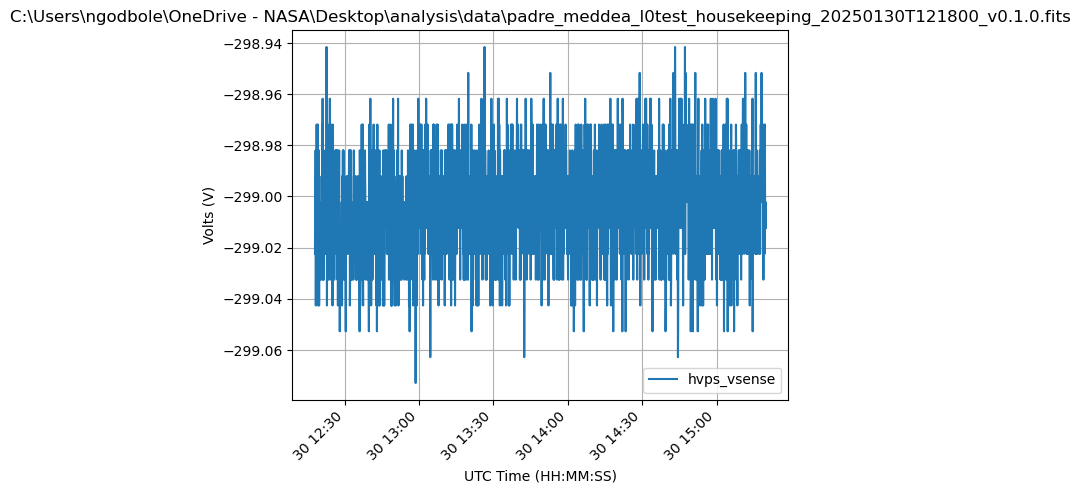

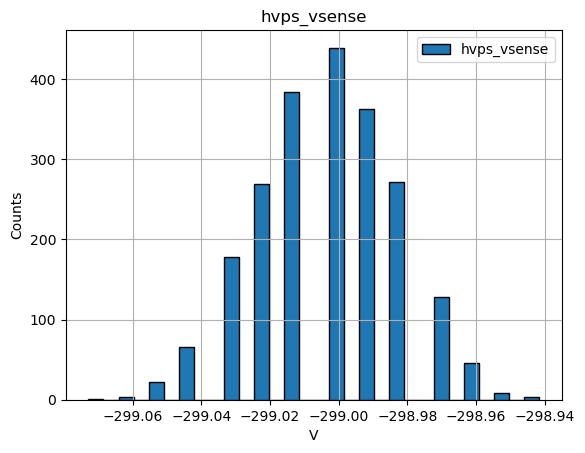

In [25]:
# Confirm that HV = -300V. 
plot_hk_converted(am_hk_ts, 'hvps_vsense', 'Volts (V)', str(am_hk_file), plot=True, hist=True)

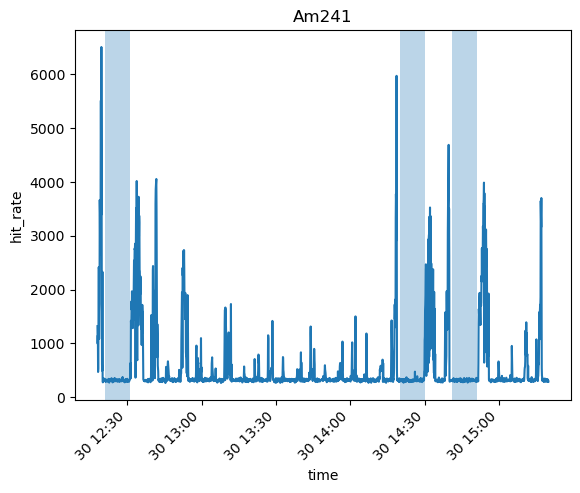

In [26]:
# Plot the hit_rate to see which intervals are not dominated by microphonics. 
plt.plot(am_hk_ts.time.to_datetime(), am_hk_ts['hit_rate'])
plt.xticks(rotation=45, ha='right') 
plt.title('Am241')
plt.ylabel('hit_rate')
plt.xlabel('time')

# select an interval not dominated by microphonics. 
am_good_tr = [(Time('2025-01-30T12:21'), Time('2025-01-30T12:31')),
              (Time('2025-01-30T14:20'), Time('2025-01-30T14:30')),
              (Time('2025-01-30T14:41'), Time('2025-01-30T14:51'))]

for this_tr in am_good_tr: 
    plt.axvspan(this_tr[0].to_datetime(), this_tr[1].to_datetime(), alpha=0.3)
plt.show()

In [27]:
am_duration = timedelta(0)
for this_time in am_good_tr: 
    print(this_time[1].to_datetime() - this_time[0].to_datetime())
    am_duration += (this_time[1].to_datetime() - this_time[0].to_datetime())

0:10:00
0:10:00
0:10:00


In [28]:
print('Total duration of "clean" measurement: ', am_duration.total_seconds()*u.s.to(u.min)*u.min)

Total duration of "clean" measurement:  30.0 min


The total duration during which "clean" data were recorded is ~ 30 minutes. 

In [29]:
am_ph_list = read_file(data_dir / am_ph_file)

In [30]:
# Stack the photon lists that correspond to the clipped times. 
filtered_am_ph_list = simple_filter_photon_list(am_ph_list, am_good_tr)

# Print information about the filtered photon list. 
print("\nFiltered PhotonList:")
print(f"Event count: {len(filtered_am_ph_list.event_list)}")
print(f"Packet count: {len(filtered_am_ph_list.pkt_list)}")
print(f"Time range: {filtered_am_ph_list.event_list.time.min().to_datetime()} - {filtered_am_ph_list.event_list.time.max().to_datetime()}")

Filtered 567793 events out of 4115451
Filtered 3995 packets out of 29532

Filtered PhotonList:
Event count: 567793
Packet count: 3995
Time range: 2025-01-30 12:21:00.000776 - 2025-01-30 14:50:59.999794


Verify the effect of baseline subtraction on the data. Analyses from last summer indicated that subtracting the baseline did not have much effect, but then again, we had only investigated data from a single Caliste-SO on the benchtop setup. We have not looked as extensively into the data from the flight configuration. 

In [31]:
# Create a copy of the original ph_list for later comparison to the baseline subtracted spectrum. 
non_bl_sub_am_list = copy.deepcopy(filtered_am_ph_list)

In [32]:
# Remove the BL. 
# Since the calibration from padre_meddea works on the 'atod' column, subtract the baseline from this column and then apply the calibration. 
filtered_am_ph_list.event_list['atod'] = (np.array(filtered_am_ph_list.event_list['atod'], dtype='float64') - np.array(filtered_am_ph_list.event_list['baseline'], dtype='float64')) + np.mean(np.array(filtered_am_ph_list.event_list['baseline'], dtype='float64'))

Now, energy-calibrate the event_list. Following a similar method to that of the Ba-133 calibration in padre_meddea, create a rough calibration for the Am241 data. 

In [33]:
# Test the calibration for Am241. 
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import specutils
from specutils import SpectralRegion, Spectrum1D
from specutils.manipulation import extract_region

from padre_meddea.util.pixels import PixelList
from padre_meddea.spectrum.spectrum import PhotonList
from scipy.signal import find_peaks

specutils.conf.do_continuum_function_check = False

AM_LINE_ENERGIES = [13.852, 17.75, 21.16, 26.245, 36.4329, 59.5409, 80.998] * u.keV

def get_calfunc_americium_rough(spec: Spectrum1D, plot: bool = False):
    """
    Given a full range Am-241 spectrum, return a rough linear calibration function
    by finding the dominant peak and using known detector characteristics.
    """
    # Find the dominant peak (should be 59.5 keV)
    max_idx = np.argmax(spec.flux)
    main_peak_channel = spec.spectral_axis[max_idx].value

    flux_smooth = spec.flux.value
    # Find peaks with minimum height and distance constraints
    peaks, _ = find_peaks(flux_smooth, height=np.max(flux_smooth)*0.1, distance=20)
    
    if len(peaks) < 2:
        # If we can't find two peaks, use a simple estimate
        # Assume linear relationship based on typical detector response
        # For most detectors: lower channel = higher energy or vice versa
        
        # Make an educated guess based on the main peak position
        if main_peak_channel > len(spec.spectral_axis) / 2:
            # Main peak in upper half - assume higher channel = lower energy
            line_energies = np.array([59.5409, 17.75])  # keV
            line_channels = np.array([main_peak_channel, main_peak_channel * 0.3])
        else:
            # Main peak in lower half - assume lower channel = lower energy  
            line_energies = np.array([17.75, 59.5409])  # keV
            line_channels = np.array([main_peak_channel, main_peak_channel * 3.5])
    else:
        # Use the two strongest peaks
        peak_heights = flux_smooth[peaks]
        sorted_indices = np.argsort(peak_heights)[::-1]  # Sort by height, descending
        
        peak1_idx = peaks[sorted_indices[0]]
        peak2_idx = peaks[sorted_indices[1]]
        
        peak1_channel = spec.spectral_axis[peak1_idx].value
        peak2_channel = spec.spectral_axis[peak2_idx].value
        
        # Assign energies based on which peak is stronger and position
        if peak1_channel < peak2_channel:
            # Peak 1 at lower channel, Peak 2 at higher channel
            line_energies = np.array([59.5409, 17.75])  # Assume lower ch = higher E
            line_channels = np.array([peak1_channel, peak2_channel])
        else:
            # Peak 1 at higher channel, Peak 2 at lower channel  
            line_energies = np.array([17.75, 59.5409])  # Assume higher ch = higher E
            line_channels = np.array([peak2_channel, peak1_channel])
    
    # Create energy-to-channel conversion
    p = np.polyfit(line_energies, line_channels, 1)  # energy -> channel
    f = np.poly1d(p)
    
    if plot:
        plt.figure()
        plt.plot(spec.spectral_axis, spec.flux)
        plt.axvline(line_channels[0], color='red', label=f'{line_energies[0]:.1f} keV')
        plt.axvline(line_channels[1], color='green', label=f'{line_energies[1]:.1f} keV')
        plt.title("Am-241 rough calibration")
        plt.xlabel("Channel")
        plt.ylabel("Counts")
        plt.legend()
        print(f"Line channels: {line_channels}")
        print(f"Line energies: {line_energies}")
        print(f"Calibration slope: {p[0]:.4f} ch/keV, intercept: {p[1]:.1f} ch")
    
    return f

def fit_peak_parabola(spec: Spectrum1D) -> float:
    """Given a spectral region with a single line, fit a parabola
    to the peak and return the position of the maximum

    Parameters
    ----------
    spec : Spectrum1D

    Returns
    -------
    peak_center : float
    """
    x = spec.spectral_axis.value
    y = spec.flux.value
    max_ind = np.argmax(y)
    
    # Handle edge cases where max is at the beginning or end of the array
    if max_ind == 0:
        # Peak is at the first point, use first 3 points
        if len(x) < 3:
            return x[max_ind]  # Return the peak position if too few points
        fit_x = x[0:3]
        fit_y = y[0:3]
    elif max_ind == len(x) - 1:
        # Peak is at the last point, use last 3 points
        if len(x) < 3:
            return x[max_ind]  # Return the peak position if too few points
        fit_x = x[-3:]
        fit_y = y[-3:]
    else:
        # Normal case: peak is in the middle
        if len(x) < 3:
            return x[max_ind]  # Return the peak position if too few points
        fit_x = [x[max_ind - 1], x[max_ind], x[max_ind + 1]]
        fit_y = [y[max_ind - 1], y[max_ind], y[max_ind + 1]]
    
    try:
        p = np.polyfit(fit_x, fit_y, 2)
        # Check if parabola opens downward (negative coefficient for x^2 term)
        if p[0] >= 0:
            # If parabola opens upward or is flat, just return the max position
            return x[max_ind]
        fit_peak = -p[1] / (2.0 * p[0])
        # Check if the fitted peak is reasonable (within the fit range)
        if fit_peak < min(fit_x) or fit_peak > max(fit_x):
            return x[max_ind]
        return fit_peak
    except (np.linalg.LinAlgError, ZeroDivisionError):
        # If fitting fails, return the original peak position
        return x[max_ind]

def fit_peaks(
    spec: Spectrum1D,
    line_centers: u.Quantity,
    plot: bool = False,
    fit_func="parabola",
    window=30,
) -> u.Quantity:
    """
    Given a spectrum and a set of approximate peak or line centers,
    perform a fit for each and return the fitted peak location for each.

    Parameters
    ----------
    spec : Spectrum1D
        The input spectrum
    line_centers : u.Quantity
        The approximate location of the line peaks
    plot : bool
        If True, then plot the data and fit for each line center region.
    fit_func : str
        The fit function for finding the peak value.
    window : int
        Number of points to consider around the line center

    Returns
    -------
    fit_centers
    """
    fit_centers = line_centers.copy()
    spec_units = line_centers[0].unit
    fit_window_halfwidth = window * spec_units
    for i, this_line in enumerate(line_centers):
        line_region = SpectralRegion(
            this_line - fit_window_halfwidth, this_line + fit_window_halfwidth
        )
        sub_spec = extract_region(spec, line_region)
        fit_centers[i] = fit_peak_parabola(sub_spec) * spec_units
        if plot:
            plt.figure()
            plt.plot(sub_spec.spectral_axis.value, sub_spec.flux, label="data")
            plt.axvline(this_line.value, color="green", label="line_center")
            plt.axvline(fit_centers[i].value, color="red", label="fit peak")
            plt.legend()
            plt.show()
    return fit_centers


def calibrate_phlist_americium_linear(ph_list: PhotonList, plot: bool = False):
    """Given a PhotonList of an Am-241 spectrum,
    perform a linear energy calibration for all detectors and pixels.

    Parameters
    ----------
    ph_list: PhotonList

    Returns
    -------
    lin_cal_params[num_asics,num_pixels,2]
        An array of linear calibration values for each pixel.
    """

    spec_bins = np.arange(0, 4097, 8, dtype=np.uint16) * u.pix
    lin_cal_params = np.zeros((4, 12, 2))
    all_pixels = PixelList.all()
    for i, this_pixel in enumerate(all_pixels):
        # fitting americium lines
        this_spec = ph_list.spectrum(pixel_list=this_pixel, bins=spec_bins)
        f = get_calfunc_americium_rough(this_spec)
        am_line_centers = f(AM_LINE_ENERGIES.value)
        fit_line_centers = fit_peaks(
            this_spec, 
            u.Quantity(am_line_centers, this_spec.spectral_axis.unit),
            window=10  # Reduced window size
        )
        if plot:
            plt.figure()
            plt.plot(this_spec.spectral_axis.value, this_spec.flux.value)
            for this_line, that_line in zip(fit_line_centers, am_line_centers):
                plt.axvline(this_line, color="red", label="fit")
                plt.axvline(that_line, color="green", label="rough")
            plt.title(f"{this_spec['label'].value}")
            plt.show()

        x = fit_line_centers
        y = AM_LINE_ENERGIES.value
        p = np.polyfit(x, y, 1)
        f = np.poly1d(p)
        if plot:
            plt.figure()
            plt.plot(x, y, "x")
            plt.plot(x, f(x.value))
            plt.title(f"{this_spec['label'].value}")
            plt.show()
        lin_cal_params[this_pixel["asic"], this_pixel["pixel"], :] = p
    return lin_cal_params

def calibrate_linear_phlist(
    ph_list: PhotonList, lin_cal_params: np.array
) -> PhotonList:
    """Given an uncalibrated PhotonList and a complete set of linear calibration parameters
    produced by calibrate_phlist_americium_linear, apply the calibration to the
    PhotonList. Adds a new energy column.

    Paramters
    ---------
    Uncalibrated PhotonList

    Linear calibration parameter array

    Returns
    -------
    calibrated PhotonList
    """
    ph_list.event_list["energy"] = np.zeros(len(ph_list.event_list["atod"]))
    for this_asic in range(4):
        for this_pixel in range(12):
            ind = (ph_list.event_list["asic"] == this_asic) * (
                ph_list.event_list["pixel"] == this_pixel
            )
            cal_func = np.poly1d(lin_cal_params[this_asic, this_pixel, :])
            ph_list.event_list["energy"][ind] = cal_func(
                ph_list.event_list["atod"][ind]
            )
    return ph_list

In [34]:
all_pixel_list = PixelList().all()

In [35]:
am_lin_cal_params = calibrate_phlist_americium_linear(filtered_am_ph_list)

In [36]:
# Calibrated Am-241 ph_list, not baseline-subtracted. 
non_bl_sub_cal_am_ph_list = calibrate_linear_phlist(non_bl_sub_am_list, am_lin_cal_params)

# Calibrated Am-241 ph_list, baseline-subtracted. 
cal_am_ph_list = calibrate_linear_phlist(filtered_am_ph_list, am_lin_cal_params)

Compare the baseline-subtracted spectrum to the non baseline-subtracted spectrum. 

C:\Users\ngodbole\AppData\Local\Temp\1\ipykernel_23488\3922276567.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=12)


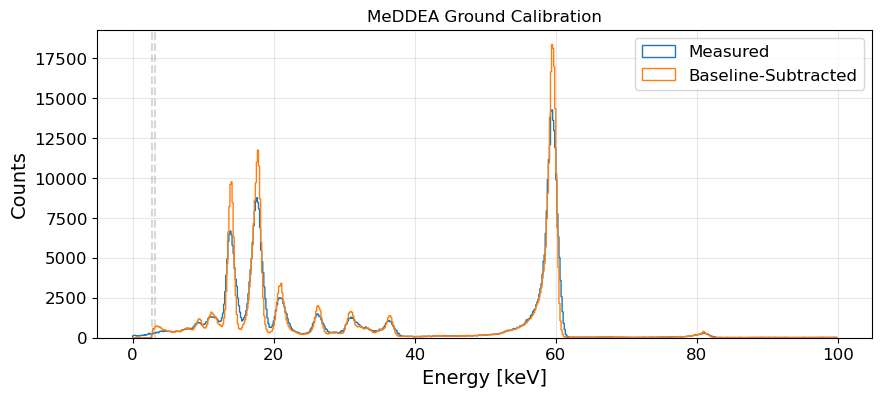

In [37]:
# Create the plots
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

ax1.set_xlabel("Energy [keV]", fontsize=14)
ax1.set_ylabel("Counts", fontsize=14)
#ax1.set_ylim(bottom=0)
#ax1.set_xlim(0, 90)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title("MeDDEA Ground Calibration / Ba-133 / Sum of all 48 pixels", 
             fontsize=16, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

plt.hist(non_bl_sub_cal_am_ph_list.event_list['energy'], histtype = 'step', bins=np.arange(0,100,0.15), label='Measured')
plt.hist(cal_am_ph_list.event_list['energy'], histtype = 'step', bins=np.arange(0,100,0.15), label='Baseline-Subtracted')
plt.axvline(2.8, color='gray', linestyle='dashed', alpha=0.3) # SPix threshold
plt.axvline(3.2, color='gray', linestyle='dashed', alpha=0.3) # LPix threshold
#plt.yscale('log')
plt.title('MeDDEA Ground Calibration')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

Subtracting the baseline noticeably improves the energy resolution, especially at lower energies. There is no reason why we should not do this when evaluating the spectral resolution of the instrument. The edge at low energies is likely due to the low energy thresholds on the small pixels (2.8 keV) and on the large pixels (3.2 keV). 

Verify the energy calibration. 

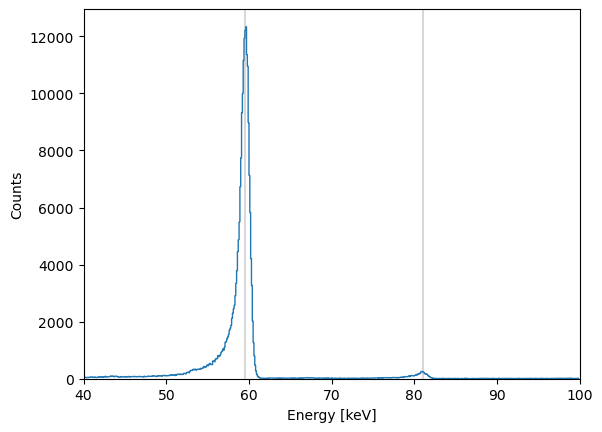

In [38]:
# Aggregated spectrum.
plt.hist(cal_am_ph_list.event_list['energy'], 
         histtype='step',
         bins=np.arange(0,100,0.1))

# Single pixel. 
#plt.hist(cal_am_ph_list.event_list['energy'][(cal_am_ph_list.event_list['asic']==0) & (cal_am_ph_list.event_list['pixel']==3)], 
#         histtype='step',
#         bins=np.arange(0,100,0.15))

for this_line in AM_LINE_ENERGIES: 
    plt.axvline(this_line, color='gray', alpha=0.3)
plt.xlim(40, 100)
#plt.title('')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')
plt.show()

The positions of the spectral features match the expected line locations. 

In [ ]:
# Olivier: Remove counts > 1 keV and < 110 keV
cal_am_ph_list.event_list = cal_am_ph_list.event_list[(cal_am_ph_list.event_list['energy'] >= 1) & (cal_am_ph_list.event_list['energy'] <= 110)]

In [40]:
am_single_events = single_events(cal_am_ph_list.event_list)

percentage of single-trigger events: 100.0 %


In [ ]:
# Export the event list for the calibrated data.
# Convert TimeSeries to Table and write to FITS.
Table(am_single_events).write('cal_am241_event_list_1to110keV_single_events_bl_sub.fits', overwrite=True)

print("All event lists exported successfully!")

All event lists exported successfully!


The 81 keV line has a larger tail than expected. Is this the case for all of the highlighted/clipped time intervals? 

Successfully accessed event_list with 521124 events
Filtering events for time range: 2025-01-30T12:21:00.000 to 2025-01-30T12:31:00.000
Successfully accessed event_list with 521124 events
Filtering events for time range: 2025-01-30T14:20:00.000 to 2025-01-30T14:30:00.000
Successfully accessed event_list with 521124 events
Filtering events for time range: 2025-01-30T14:41:00.000 to 2025-01-30T14:51:00.000


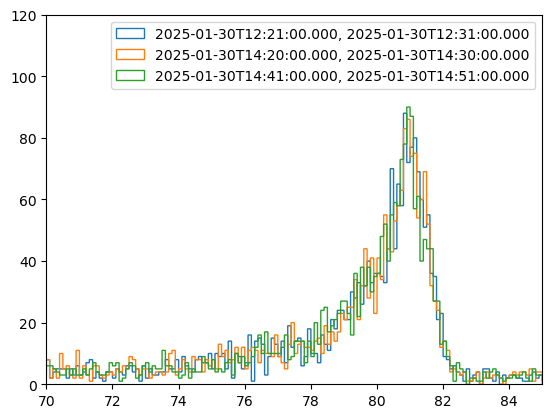

In [ ]:
for start_time, end_time in am_good_tr: 
    print(f"Successfully accessed event_list with {len(am_single_events)} events")
    print(f"Filtering events for time range: {start_time} to {end_time}")
    # Create time mask for this range
    event_mask = ((am_single_events.time >= start_time) & (am_single_events.time <= end_time))
    filtered_event_list = am_single_events[event_mask]
    plt.hist(filtered_event_list['energy'], histtype='step', bins=np.arange(0,100,0.1), label=f'{start_time}, {end_time}')

plt.legend()
plt.xlim(70,85)
plt.ylim(0,120)
plt.show()

This data has already been calibrated and filtered to include single events only. The amount of tailing is comparable for all time intervals. 

Olivier suggested filtering the event lists such that only counts from Pixels 9, 10, and 11 are kept. Since these are small pixels, the energy resolution should be better than their large counterparts. Pixel 8 is excluded from this list, since it physically touches the Guard Ring, and is therefore the likelihood of it experiencing charge sharing events (which lead to increased tailing and poorer energy resolution) with the Guard Ring is higher. We want to eliminate this possibility, hence we are only looking at events from Pixels 9, 10, and 11. 

In [43]:
am241_single_events_spix = am_single_events[(am_single_events['pixel'] == 9) | (am_single_events['pixel'] == 10) | (am_single_events['pixel'] == 11)]

Percentage of single-trigger events:  93.33686770811318 %


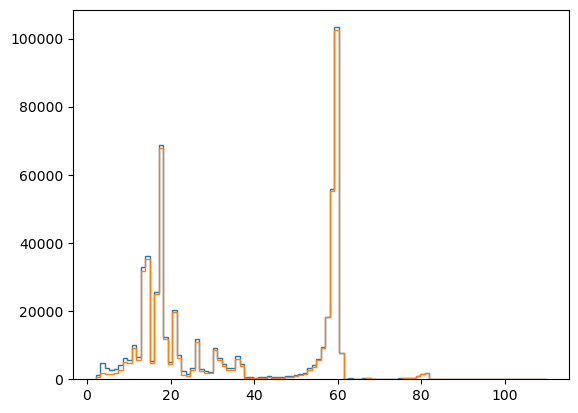

In [44]:
plt.hist(cal_am_ph_list.event_list['energy'], 
         histtype='step',
         bins=100)

plt.hist(am_single_events['energy'], 
         histtype='step',
         bins=100)

print('Percentage of single-trigger events: ', len(am_single_events['energy']) / len(cal_am_ph_list.event_list['energy'])*100, '%' )
plt.show()

In [45]:
print('Total count rate (single-events only): ', np.sum(agg_spectrum(am_single_events).flux) / (am_duration.total_seconds()*u.s))

Total count rate (single-events only):  289.5133333333333 ct / s


In [46]:
np.savez(f'aggregated_am241_data_1kevto110kev_single_events_bl_sub.npz', 
         energy=agg_spectrum(am_single_events).spectral_axis.value, 
         flux=agg_spectrum(am_single_events).flux)

In [47]:
np.savez(f'aggregated_am241_data_1kevto110kev_spix_single_events_bl_sub.npz', 
         energy=agg_spectrum(am241_single_events_spix).spectral_axis.value, 
         flux=agg_spectrum(am241_single_events_spix).flux)

Sanity check; see how the spectra look for individual ASICs. 

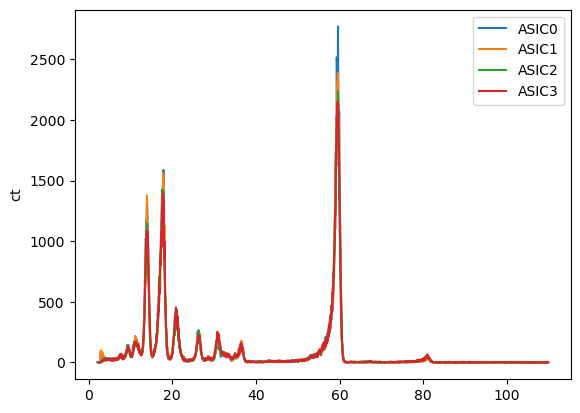

In [48]:
for this_asic in asics_list: 
    spec = agg_spectrum(event_list=am_single_events, asic=this_asic)

    #np.savez(f'asic{this_asic}_am241_data.npz', 
    #     energy=spec.spectral_axis.value, 
    #     flux=spec.flux)
    
    plt.plot(spec.spectral_axis.value, spec.flux, label=f'ASIC{this_asic}')
    plt.legend()
plt.show()

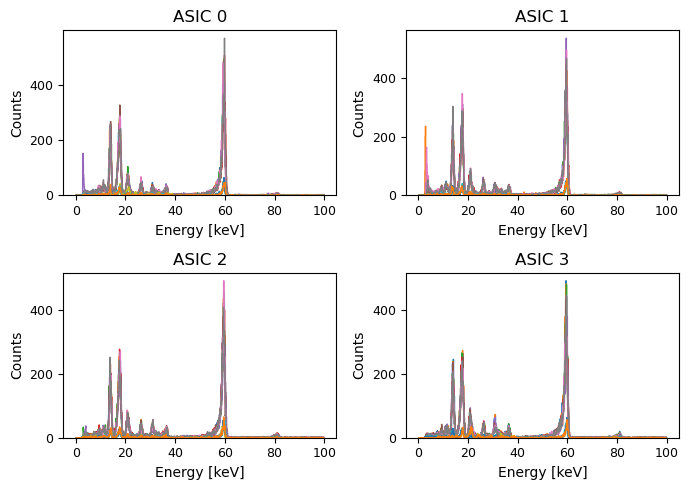

In [49]:
fig, ax = plt.subplots(2, 2, figsize=(7,5))
for this_asic in asics_list:
    plt.subplot(2, 2, this_asic+1)
    # Filter once per ASIC to reduce repeated operations
    asic_data = cal_am_ph_list.event_list[cal_am_ph_list.event_list['asic']==this_asic]
    for this_pixel in pixels_list:
        pixel_data = asic_data[asic_data['pixel']==this_pixel]['energy']
        plt.hist(pixel_data, 
                 bins=np.arange(0,100,0.1), 
                 histtype='step',
                 label=f'Pixel {this_pixel}')
    plt.title(f'ASIC {this_asic}', fontsize=12)
    plt.xlabel('Energy [keV]', fontsize=10)
    plt.ylabel('Counts', fontsize=10)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    # plt.legend(fontsize=5, loc='upper right')  # Uncomment if needed
fig.tight_layout()
plt.show()  # Only show once at the end

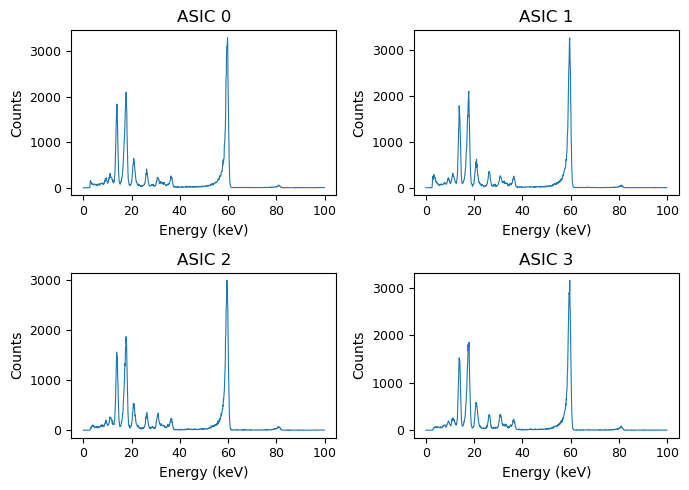

In [50]:
fig, ax = plt.subplots(2, 2, figsize=(7,5))
for this_asic in asics_list:
    plt.subplot(2, 2, this_asic+1)
    this_flux=0
    for this_pixel in pixels_list:
        select_pixel=PixelList(asics=[this_asic], pixels=[this_pixel])
        this_spectrum=cal_am_ph_list.spectrum(pixel_list=select_pixel, calibrate=True)
        this_flux+=this_spectrum.flux
    #np.savez(f'asic{this_asic}_am241_data.npz', 
    #     energy=this_spectrum.spectral_axis.value, 
    #     flux=this_flux.value)
    #for this_roi in am_rois: 
    #    plt.axvspan(this_roi[0], this_roi[1], alpha=0.3)
    plt.plot(this_spectrum.spectral_axis, this_flux, linewidth=0.8)
    plt.title(f'ASIC {this_asic}', fontsize=12)
    plt.xlabel('Energy (keV)', fontsize=10)
    plt.ylabel('Counts', fontsize=10)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
fig.tight_layout()
plt.show()